# Analyzing the Relationship Between Daily Habits and Productivity

This notebook presents the data collection, exploratory data analysis (EDA), and statistical modeling of daily habits and their effect on productivity.

In [23]:
import pandas as pd

In [24]:
df = pd.read_csv("/content/data.csv")
df.shape

(56, 10)

In [25]:
df

,date,sleep_hours,sleep_quality,morning_mood,energy,study_hours,phone_usage,productivity,stress,is_weekend
0,2026-03-10,6.5,2,2,2,4.0,7.2,2,2,0
1,2026-03-11,7.0,3,2,2,4.5,4.5,3,2,0
2,2026-03-12,5.5,2,1,2,3.0,7.1,2,2,0
3,2026-03-13,9.0,1,3,1,0.0,6.2,1,1,0
4,2026-03-14,7.0,3,3,3,0.0,8.8,2,1,1
5,2026-03-15,7.0,3,3,3,0.0,7.8,1,1,1
6,2026-03-16,8.0,2,2,2,3.0,5.7,3,2,0
7,2026-03-17,7.0,3,3,3,6.0,5.0,3,2,0
8,2026-03-18,6.0,2,2,2,5.0,4.1,2,2,0
9,2026-03-19,6.5,1,1,2,3.0,3.2,3,2,0


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56 entries, 0 to 55
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           56 non-null     object 
 1   sleep_hours    56 non-null     float64
 2   sleep_quality  56 non-null     int64  
 3   morning_mood   56 non-null     int64  
 4   energy         56 non-null     int64  
 5   study_hours    56 non-null     float64
 6   phone_usage    56 non-null     float64
 7   productivity   56 non-null     int64  
 8   stress         56 non-null     int64  
 9   is_weekend     56 non-null     int64  
dtypes: float64(3), int64(6), object(1)
memory usage: 4.5+ KB


In [27]:
df.describe()

,sleep_hours,sleep_quality,morning_mood,energy,study_hours,phone_usage,productivity,stress,is_weekend
count,56.000000,56.000000,56.000000,56.000000,56.000000,56.00000,56.000000,56.000000,56.000000
mean,7.330357,2.410714,2.696429,2.517857,2.946429,6.51250,2.339286,2.142857,0.285714
std,1.356053,1.074951,1.158677,0.808839,2.336817,2.19769,1.014025,1.182118,0.455842
min,4.500000,1.000000,1.000000,1.000000,0.000000,2.90000,1.000000,1.000000,0.000000
25%,6.500000,1.000000,2.000000,2.000000,0.000000,5.00000,2.000000,1.000000,0.000000
50%,7.000000,3.000000,3.000000,2.000000,3.000000,6.10000,2.000000,2.000000,0.000000
75%,8.125000,3.000000,3.000000,3.000000,5.000000,7.80000,3.000000,3.000000,1.000000
max,10.000000,5.000000,5.000000,5.000000,8.000000,12.30000,5.000000,5.000000,1.000000


The dataset contains 56 observations with both numerical and ordinal variables. Productivity values are mostly concentrated between 2 and 3, indicating moderate productivity levels across most days.

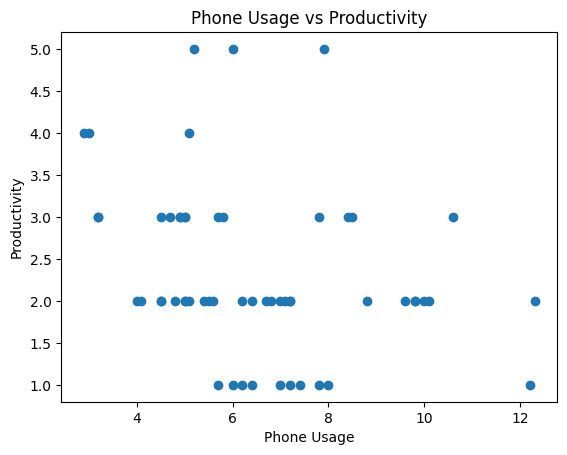

In [28]:
import matplotlib.pyplot as plt
plt.scatter(df["phone_usage"], df["productivity"])
plt.xlabel("Phone Usage")
plt.ylabel("Productivity")
plt.title("Phone Usage vs Productivity")
plt.show()

The scatter plot shows no clear pattern, suggesting a weak or no relationship between phone usage and productivity.

In [29]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

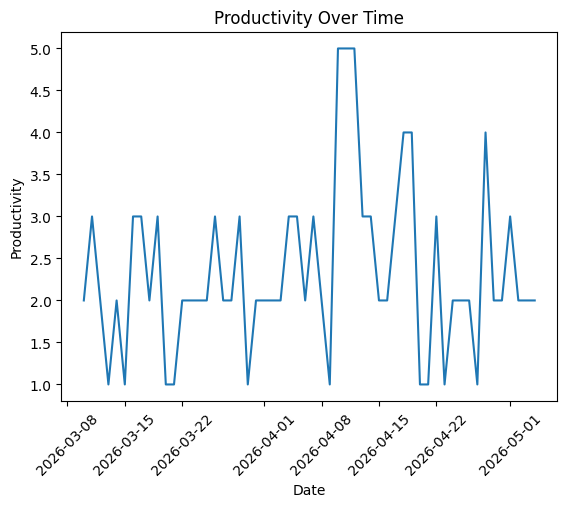

In [30]:
plt.figure()
plt.plot(df["date"], df["productivity"])
plt.xticks(rotation=45)
plt.title("Productivity Over Time")
plt.xlabel("Date")
plt.ylabel("Productivity")
plt.show()

Productivity fluctuates over time, indicating that daily variations are likely driven by short-term factors rather than a consistent long-term trend.

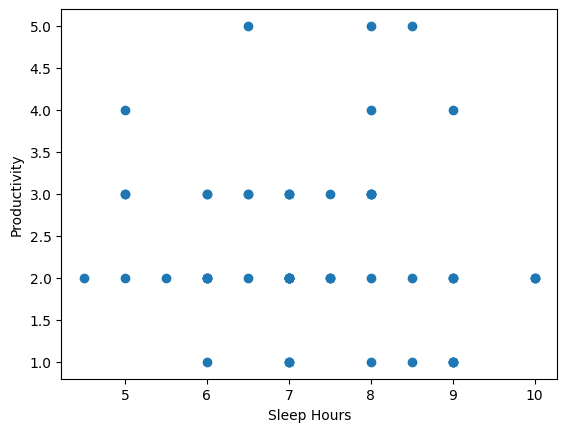

In [31]:
plt.scatter(df["sleep_hours"], df["productivity"])
plt.xlabel("Sleep Hours")
plt.ylabel("Productivity")
plt.show()

Sleep hours do not show a clear relationship with productivity.

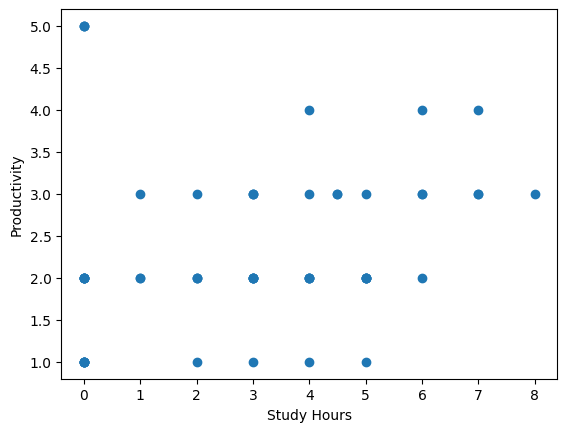

In [32]:
plt.scatter(df["study_hours"], df["productivity"])
plt.xlabel("Study Hours")
plt.ylabel("Productivity")
plt.show()

A weak positive relationship is observed between study hours and productivity.

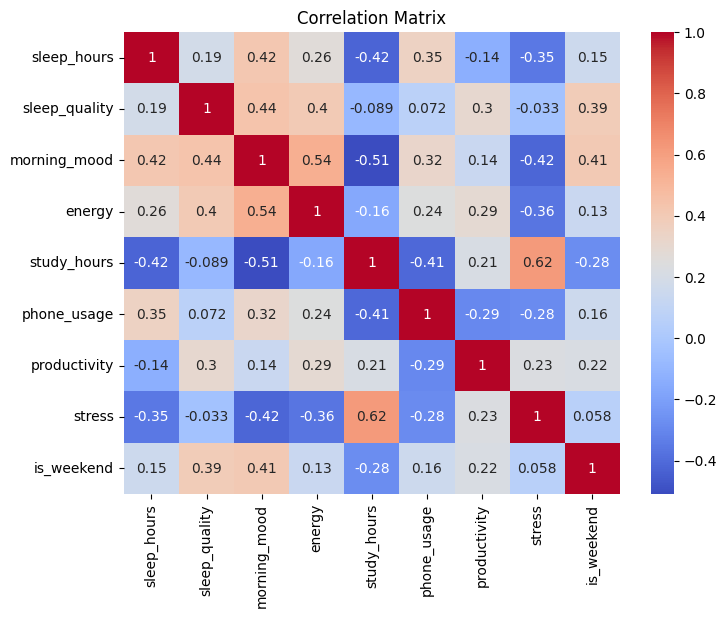

In [33]:
import seaborn as sns
df_numeric = df.select_dtypes(include=["number"])
plt.figure(figsize=(8,6))
sns.heatmap(df_numeric.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

Energy shows the highest correlation with productivity (r ≈ 0.29), although the relationship is moderate rather than strong. The relatively weak correlations are expected in behavioral data, where outcomes are typically influenced by multiple interacting factors.

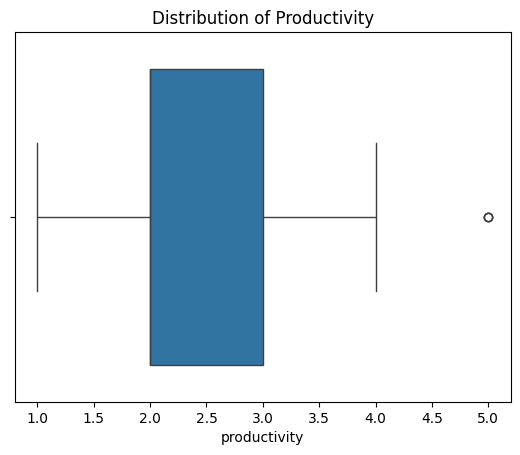

In [34]:
sns.boxplot(x=df["productivity"])
plt.title("Distribution of Productivity")
plt.show()

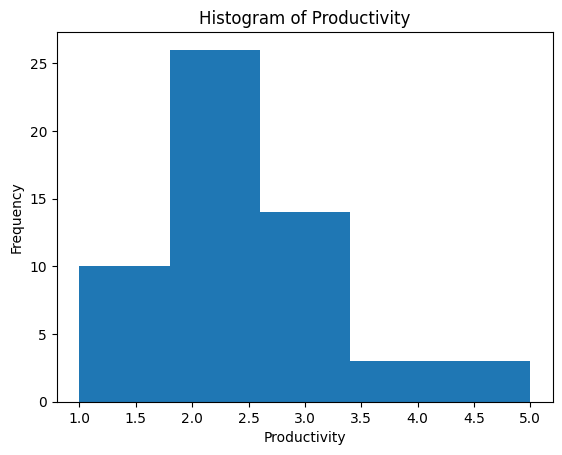

In [35]:
plt.hist(df["productivity"], bins=5)
plt.title("Histogram of Productivity")
plt.xlabel("Productivity")
plt.ylabel("Frequency")
plt.show()

The histogram shows that productivity is mostly concentrated around low to moderate values.

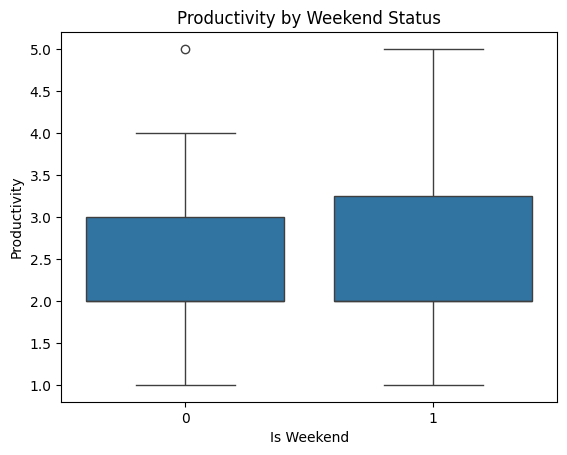

,productivity
is_weekend,
0,2.2000
1,2.6875


In [36]:
sns.boxplot(x="is_weekend", y="productivity", data=df)
plt.title("Productivity by Weekend Status")
plt.xlabel("Is Weekend")
plt.ylabel("Productivity")
plt.show()
df.groupby("is_weekend")["productivity"].mean()

Productivity appears slightly higher on weekends; however, the difference is not substantial, suggesting that weekend status alone is not a strong determinant of productivity.

In [37]:
from scipy.stats import mannwhitneyu
weekday = df[df["is_weekend"] == 0]["productivity"]
weekend = df[df["is_weekend"] == 1]["productivity"]
stat, p_value = mannwhitneyu(weekday, weekend)
print("Mann-Whitney U test:", stat, p_value)

Mann-Whitney U test: 256.0 0.21918161374763467


The Mann-Whitney U test indicates that the difference between weekday and weekend productivity is not statistically significant (p > 0.05), suggesting that weekend status does not have a strong impact on productivity.

In [38]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

X = df[["sleep_hours", "study_hours", "phone_usage", "energy", "morning_mood"]]
y = df["productivity"]
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
print("Coefficients:", model.coef_)
print("R2:", r2_score(y, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y, y_pred)))

Coefficients: [-0.08676553  0.08458614 -0.14734778  0.39560899  0.18840142]
R2: 0.2730994122008462
RMSE: 0.8567882751628941


The regression model explains approximately 27% of the variance in productivity, indicating a modest predictive power. This suggests that productivity is influenced by additional factors not captured in the model.

In [39]:
from scipy.stats import pearsonr

variables = ["energy", "morning_mood", "phone_usage", "sleep_hours", "study_hours", "stress"]
for var in variables:
    corr, p_value = pearsonr(df[var], df["productivity"])
    print(f"{var} vs Productivity: correlation={corr:.3f}, p-value={p_value:.4f}")

energy vs Productivity: correlation=0.292, p-value=0.0291
morning_mood vs Productivity: correlation=0.136, p-value=0.3187
phone_usage vs Productivity: correlation=-0.295, p-value=0.0274
sleep_hours vs Productivity: correlation=-0.136, p-value=0.3180
study_hours vs Productivity: correlation=0.215, p-value=0.1116
stress vs Productivity: correlation=0.232, p-value=0.0855


Pearson correlation results indicate that energy has a statistically significant positive relationship with productivity, while phone usage shows a significant negative relationship. Other variables exhibit weak or non-significant associations.

In [40]:
from scipy.stats import spearmanr

for var in variables:
    corr, p_value = spearmanr(df[var], df["productivity"])
    print(f"{var} vs Productivity: Spearman correlation={corr:.3f}, p-value={p_value:.4f}")

energy vs Productivity: Spearman correlation=0.180, p-value=0.1836
morning_mood vs Productivity: Spearman correlation=-0.051, p-value=0.7107
phone_usage vs Productivity: Spearman correlation=-0.346, p-value=0.0090
sleep_hours vs Productivity: Spearman correlation=-0.183, p-value=0.1774
study_hours vs Productivity: Spearman correlation=0.337, p-value=0.0111
stress vs Productivity: Spearman correlation=0.351, p-value=0.0080


Spearman correlation analysis reveals stronger monotonic relationships compared to Pearson, particularly for phone usage, study hours, and stress. This suggests that some variables may influence productivity in a non-linear or ordinal manner.

Energy shows a statistically significant positive relationship with productivity (p < 0.05).
Phone usage shows a significant negative relationship.
However, morning mood is not statistically significant (p > 0.05).

Overall, the results suggest that energy has the most consistent and statistically significant relationship with productivity, while other variables show weaker or context-dependent effects. Due to the relatively small sample size (n=56), the results should be interpreted with caution.

#MACHINE LEARNING MODELS
 Goal: Predict productivity using regression
 and classification approaches.

 Models: Linear Regression, RF Regressor, Logistic Regression, RF Classifier

In [41]:
from sklearn.model_selection import train_test_split

features = ["sleep_hours", "sleep_quality", "study_hours",
            "phone_usage", "energy", "morning_mood", "stress", "is_weekend"]
X = df[features]
y = df["productivity"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train size: {X_train.shape[0]}")
print(f"Test size: {X_test.shape[0]}")

Train size: 44
Test size: 12


In [42]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import cross_val_score
import numpy as np

#Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_r2 = r2_score(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_cv = cross_val_score(lr, X, y, cv=5, scoring="r2").mean()
print("LINEAR REGRESSION")
print(f"  R2 (test):        {lr_r2:.3f}")
print(f"  RMSE (test):      {lr_rmse:.3f}")
print(f"  R2 (CV-5):        {lr_cv:.3f}")

#Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_r2 = r2_score(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_cv = cross_val_score(rf, X, y, cv=5, scoring="r2").mean()
print("\nRANDOM FOREST REGRESSOR")
print(f"  R2 (test):        {rf_r2:.3f}")
print(f"  RMSE (test):      {rf_rmse:.3f}")
print(f"  R2 (CV-5):        {rf_cv:.3f}")

LINEAR REGRESSION
  R2 (test):        0.257
  RMSE (test):      0.920
  R2 (CV-5):        -0.733

RANDOM FOREST REGRESSOR
  R2 (test):        0.590
  RMSE (test):      0.683
  R2 (CV-5):        -0.392


Although the Random Forest Regressor outperforms Linear Regression on the test set (R²=0.590 vs 0.257), both models show negative cross-validation scores. This indicates poor generalization, likely due to the small dataset size (n=56) and limited signal in the features.

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.model_selection import cross_val_score

#Logistic Regression
log = LogisticRegression(max_iter=1000, random_state=42)
log.fit(X_train, y_train)
log_pred = log.predict(X_test)
log_acc = accuracy_score(y_test, log_pred)
log_f1 = f1_score(y_test, log_pred, average="weighted")
log_cv = cross_val_score(log, X, y, cv=5, scoring="accuracy").mean()
print("LOGISTIC REGRESSION")
print(f"  Accuracy (test):  {log_acc:.3f}")
print(f"  F1 (test):        {log_f1:.3f}")
print(f"  Accuracy (CV-5):  {log_cv:.3f}")

#Random Forest Classifier
rfc = RandomForestClassifier(n_estimators=100, random_state=42)
rfc.fit(X_train, y_train)
rfc_pred = rfc.predict(X_test)
rfc_acc = accuracy_score(y_test, rfc_pred)
rfc_f1 = f1_score(y_test, rfc_pred, average="weighted")
rfc_cv = cross_val_score(rfc, X, y, cv=5, scoring="accuracy").mean()
print("\nRANDOM FOREST CLASSIFIER")
print(f"  Accuracy (test):  {rfc_acc:.3f}")
print(f"  F1 (test):        {rfc_f1:.3f}")
print(f"  Accuracy (CV-5):  {rfc_cv:.3f}")

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


LOGISTIC REGRESSION
  Accuracy (test):  0.667
  F1 (test):        0.649
  Accuracy (CV-5):  0.426


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(



RANDOM FOREST CLASSIFIER
  Accuracy (test):  0.667
  F1 (test):        0.649
  Accuracy (CV-5):  0.373


The classification models achieve moderate accuracy (0.667); however, the imbalanced class distribution (some productivity levels have only 3 members) limits their reliability. The cross-validation warning reflects this imbalance.

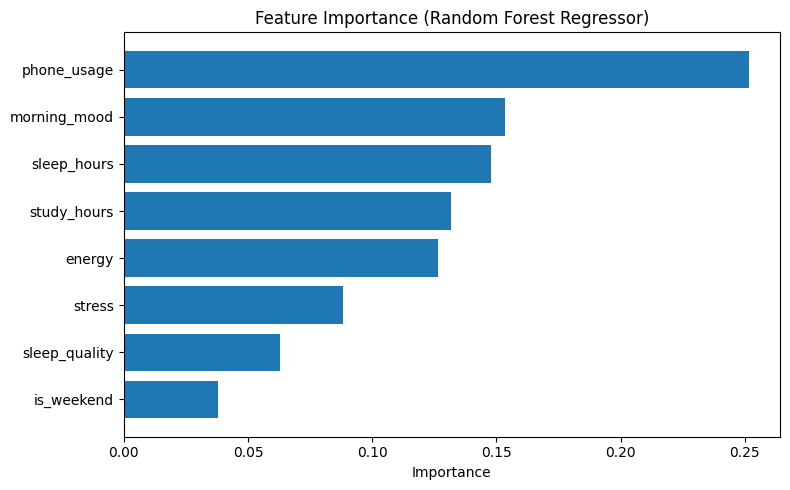

              Model           Type  Test Score  CV Score   Metric
  Linear Regression     Regression       0.257    -0.733       R²
       RF Regressor     Regression       0.590    -0.392       R²
Logistic Regression Classification       0.667     0.426 Accuracy
      RF Classifier Classification       0.667     0.373 Accuracy


In [44]:
import matplotlib.pyplot as plt
import pandas as pd

#Feature Importance (Random Forest)
importance_df = pd.DataFrame({
    "feature": features,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=True)
plt.figure(figsize=(8, 5))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.title("Feature Importance (Random Forest Regressor)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

#Model Karşılaştırma Tablosu
results = pd.DataFrame({
    "Model": ["Linear Regression", "RF Regressor",
              "Logistic Regression", "RF Classifier"],
    "Type": ["Regression", "Regression",
             "Classification", "Classification"],
    "Test Score": [0.257, 0.590, 0.667, 0.667],
    "CV Score": [-0.733, -0.392, 0.426, 0.373],
    "Metric": ["R²", "R²", "Accuracy", "Accuracy"]
})
print(results.to_string(index=False))

Phone usage emerges as the most important feature in the Random Forest model, which contrasts with the Pearson correlation analysis where energy ranked highest. This discrepancy suggests that machine learning models capture non-linear relationships that simple correlation cannot detect.